
# DATA 304 — Module 10: Dates and Times 

This notebook demonstrates:
- Parsing and normalizing timestamps
- Extracting date features
- Time arithmetic and corrections
- Handling time zones and DST
- Cleaning and validating temporal data
- Aggregation, resampling, grouping, rolling metrics
- Temporal joins (`merge_asof`)


## Setup

In [1]:

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo  # Python 3.9+
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)

print("pandas:", pd.__version__)
print("numpy:", np.__version__)


pandas: 3.0.0
numpy: 2.4.1


## Create sample data

In [2]:

# Synthetic transactions with mixed date formats
raw_dates = [
    "2025-10-20", "20/10/2025", "Oct 21, 2025", "2025/10/22", "10-23-2025", "invalid",
    "2025-10-24 10:15:00", "2025-10-24 10:15:00"  # duplicate
]
sales = [100, 120, 130, 90, 80, 75, 200, 200]

transactions = pd.DataFrame({"raw_date": raw_dates, "sales": sales})
transactions


,raw_date,sales
0,2025-10-20,100
1,20/10/2025,120
2,"Oct 21, 2025",130
3,2025/10/22,90
4,10-23-2025,80
5,invalid,75
6,2025-10-24 10:15:00,200
7,2025-10-24 10:15:00,200


## Parsing strings → datetimes

In [3]:

# Flexible parser with error coercion
transactions["timestamp"] = pd.to_datetime(transactions["raw_date"], errors="coerce")
transactions[["raw_date", "timestamp", "sales"]]


,raw_date,timestamp,sales
0,2025-10-20,2025-10-20,100
1,20/10/2025,NaT,120
2,"Oct 21, 2025",NaT,130
3,2025/10/22,NaT,90
4,10-23-2025,NaT,80
5,invalid,NaT,75
6,2025-10-24 10:15:00,NaT,200
7,2025-10-24 10:15:00,NaT,200


### When you know the exact format

In [4]:

# Example of explicit format (day-first)
ex = pd.Series(["20/10/2025", "21/10/2025", "22/10/2025"])
parsed = pd.to_datetime(ex, format="%d/%m/%Y")
pd.DataFrame({"original": ex, "parsed": parsed})


,original,parsed
0,20/10/2025,2025-10-20
1,21/10/2025,2025-10-21
2,22/10/2025,2025-10-22


## Extracting date features

In [5]:

parsed_ok = transactions.dropna(subset=["timestamp"]).copy()
parsed_ok["year"] = parsed_ok["timestamp"].dt.year
parsed_ok["month"] = parsed_ok["timestamp"].dt.month
parsed_ok["day"] = parsed_ok["timestamp"].dt.day
parsed_ok["weekday"] = parsed_ok["timestamp"].dt.weekday  # Monday=0
parsed_ok["hour"] = parsed_ok["timestamp"].dt.hour
parsed_ok[["timestamp", "year", "month", "day", "weekday", "hour", "sales"]]


,timestamp,year,month,day,weekday,hour,sales
0,2025-10-20,2025,10,20,0,0,100


## Time arithmetic and corrections

In [6]:

dt = datetime(2025, 10, 29, 8, 0, 0)
next_day = dt + timedelta(days=1)
gap = datetime.now() - dt
dt_fixed = dt.replace(hour=10, minute=30)

print("dt:", dt)
print("next_day:", next_day)
print("gap total seconds:", int(gap.total_seconds()))
print("dt_fixed:", dt_fixed)


dt: 2025-10-29 08:00:00
next_day: 2025-10-30 08:00:00
gap total seconds: 14621039
dt_fixed: 2025-10-29 10:30:00


## Handling time zones and DST

In [7]:
tz_demo = pd.DataFrame({
    "local_time": pd.to_datetime([
        "2025-03-09 01:30:00",  # spring forward: nonexistent local time
        "2025-11-02 01:30:00"   # fall back: ambiguous local time
    ])
})

# Boolean mask: which rows are the ambiguous fallback time?
amb_mask = tz_demo["local_time"].dt.strftime("%Y-%m-%d %H:%M:%S").eq("2025-11-02 01:30:00")

tz_demo["eastern"] = tz_demo["local_time"].dt.tz_localize(
    "US/Eastern",
    ambiguous=amb_mask,           # True for rows treated as DST; False for standard time
    nonexistent="shift_forward"   # resolve spring-forward gaps
)
tz_demo["utc"] = tz_demo["eastern"].dt.tz_convert("UTC")
tz_demo


,local_time,eastern,utc
0,2025-03-09 01:30:00,2025-03-09 01:30:00-05:00,2025-03-09 06:30:00+00:00
1,2025-11-02 01:30:00,2025-11-02 01:30:00-04:00,2025-11-02 05:30:00+00:00


In [8]:
spring = datetime(2025, 3, 9, 1, 30, tzinfo=ZoneInfo("US/Eastern"))
fall_1 = datetime(2025, 11, 2, 1, 30, tzinfo=ZoneInfo("US/Eastern"))
fall_2 = datetime(2025, 11, 2, 1, 30, tzinfo=ZoneInfo("US/Eastern"))
fall_2 = fall_2.replace(fold=1)  # standard-time instance

print("Spring forward:", spring, "→", spring.astimezone(ZoneInfo("UTC")))
print("Fall back (DST):", fall_1, "→", fall_1.astimezone(ZoneInfo("UTC")))
print("Fall back (Standard):", fall_2, "→", fall_2.astimezone(ZoneInfo("UTC")))

Spring forward: 2025-03-09 01:30:00-05:00 → 2025-03-09 06:30:00+00:00
Fall back (DST): 2025-11-02 01:30:00-04:00 → 2025-11-02 05:30:00+00:00
Fall back (Standard): 2025-11-02 01:30:00-05:00 → 2025-11-02 06:30:00+00:00


## Cleaning timestamps

In [9]:

clean = transactions.copy()
# Remove duplicates on timestamp after parsing; sort
clean["timestamp"] = pd.to_datetime(clean["raw_date"], errors="coerce")
clean = clean.drop_duplicates("timestamp").sort_values("timestamp")

# Fill missing timestamps by forward-fill on sales (demo purposes)
clean["sales"] = clean["sales"].astype(float)
clean["sales_ffill"] = clean["sales"].ffill()

# Validate range
mask = clean["timestamp"].between("2000-01-01", "2030-12-31")
clean = clean.loc[mask]
clean[["raw_date", "timestamp", "sales", "sales_ffill"]]


,raw_date,timestamp,sales,sales_ffill
0,2025-10-20,2025-10-20,100.0,100.0


## Aggregation and resampling

Daily mean:


,value
timestamp,
2025-10-01,108.208333
2025-10-02,104.833333
2025-10-03,110.125000
2025-10-04,110.625000
2025-10-05,106.833333


Weekly sum:


,value
timestamp,
2025-10-05,12975
2025-10-12,5291


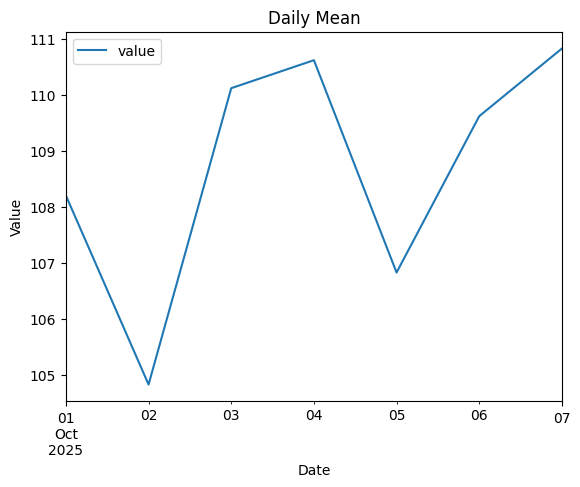

In [10]:

# Build a higher-frequency example
rng = pd.date_range("2025-10-01", periods=24*7, freq="h")  # hourly for a week
np.random.seed(0)
values = np.random.randint(80, 140, size=len(rng))

series = pd.DataFrame({"timestamp": rng, "value": values}).set_index("timestamp")

daily_mean = series.resample("D").mean()
weekly_sum = series.resample("W").sum()

print("Daily mean:")
display(daily_mean.head())

print("Weekly sum:")
display(weekly_sum)

# Plot daily mean (single plot, matplotlib, no explicit colors)
daily_mean.plot(title="Daily Mean")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()


## Upsampling and interpolation

Downsampled (3H):


,value
timestamp,
2025-10-01 00:00:00,128.000000
2025-10-01 03:00:00,100.666667
2025-10-01 06:00:00,97.000000
2025-10-01 09:00:00,110.000000
2025-10-01 12:00:00,101.666667


Upsampled (H) with NaNs:


,value
timestamp,
2025-10-01 00:00:00,128.000000
2025-10-01 01:00:00,NaN
2025-10-01 02:00:00,NaN
2025-10-01 03:00:00,100.666667
2025-10-01 04:00:00,NaN
2025-10-01 05:00:00,NaN
2025-10-01 06:00:00,97.000000
2025-10-01 07:00:00,NaN
2025-10-01 08:00:00,NaN


Interpolated:


,value
timestamp,
2025-10-01 00:00:00,128.000000
2025-10-01 01:00:00,118.888889
2025-10-01 02:00:00,109.777778
2025-10-01 03:00:00,100.666667
2025-10-01 04:00:00,99.444444
2025-10-01 05:00:00,98.222222
2025-10-01 06:00:00,97.000000
2025-10-01 07:00:00,101.333333
2025-10-01 08:00:00,105.666667


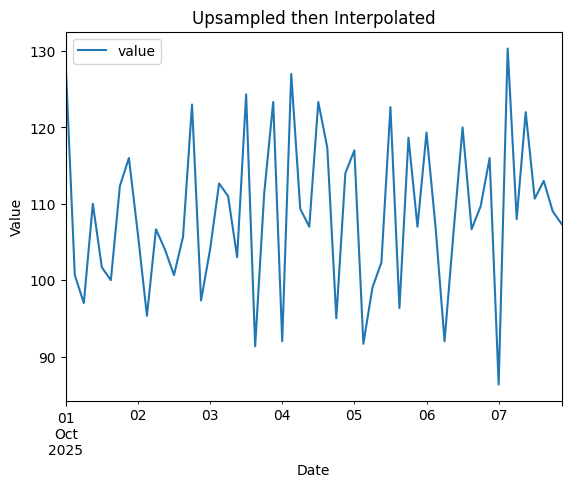

In [11]:

# Downsample hourly → 3-hourly to simulate missing points, then upsample back
down = series.resample("3h").mean()
up = down.resample("h").asfreq()  # introduce NaNs
interp = up.interpolate()

print("Downsampled (3H):")
display(down.head())
print("Upsampled (H) with NaNs:")
display(up.head(10))
print("Interpolated:")
display(interp.head(10))

interp.plot(title="Upsampled then Interpolated")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()


## Temporal grouping and rolling metrics

Monthly sum:


timestamp
2025-10-31    18266
Freq: ME, Name: value, dtype: int64

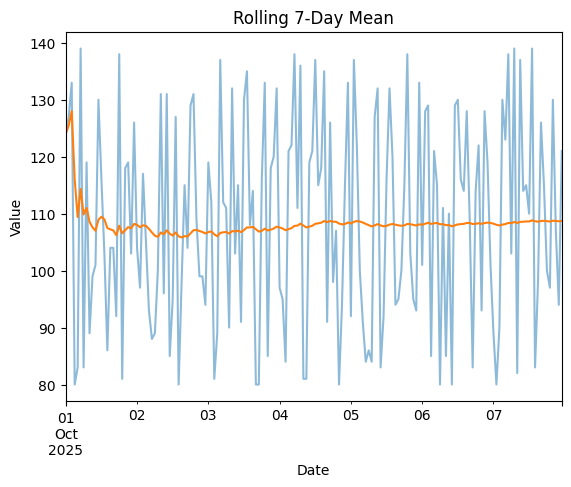

In [12]:

monthly_sum = series.groupby(pd.Grouper(freq="ME"))["value"].sum()
rolling_7d = series.rolling("7D")["value"].mean()

print("Monthly sum:")
display(monthly_sum.head())

ax = series["value"].plot(alpha=0.5, title="Rolling 7-Day Mean")
rolling_7d.plot(ax=ax)
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()


## Temporal joins (`merge_asof`)

In [13]:

# df1: sparse events; df2: more frequent reference series
df1 = pd.DataFrame({
    "timestamp": pd.to_datetime(["2025-10-01 10:00:01", "2025-10-01 10:00:05", "2025-10-01 10:02:10"]),
    "event": ["A", "B", "C"]
}).sort_values("timestamp")

df2 = pd.DataFrame({
    "timestamp": pd.to_datetime(["2025-10-01 10:00:00", "2025-10-01 10:00:06", "2025-10-01 10:02:00", "2025-10-01 10:03:00"]),
    "price": [101.5, 101.7, 101.4, 101.9]
}).sort_values("timestamp")

merged = pd.merge_asof(df1, df2, on="timestamp", direction="nearest", tolerance=pd.Timedelta("2s"))
merged


,timestamp,event,price
0,2025-10-01 10:00:01,A,101.5
1,2025-10-01 10:00:05,B,101.7
2,2025-10-01 10:02:10,C,NaN


## Validation checks

In [14]:

# Monotonicity and duplicates
is_mono = series.index.is_monotonic_increasing
has_dups = series.index.duplicated().any()
print("Monotonic increasing index:", is_mono)
print("Any duplicate timestamps:", has_dups)

# Frequency inference
freq = pd.infer_freq(series.index)
print("Inferred frequency:", freq)

# Interval sanity
interval_demo = pd.DataFrame({
    "start_time": pd.to_datetime(["2025-10-01 10:00", "2025-10-01 11:00"]),
    "end_time":   pd.to_datetime(["2025-10-01 10:30", "2025-10-01 10:45"])  # second one invalid (end < start)
})
interval_demo.assign(valid=(interval_demo["start_time"] < interval_demo["end_time"]))


Monotonic increasing index: True
Any duplicate timestamps: False
Inferred frequency: h


,start_time,end_time,valid
0,2025-10-01 10:00:00,2025-10-01 10:30:00,True
1,2025-10-01 11:00:00,2025-10-01 10:45:00,False
